<a href="https://colab.research.google.com/github/Josiah-Kunz/MGN-Public/blob/main/examples/colab/2_meshgraphnet/2_apply_mgn_to_unseen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Example applying a pretrained MGN model to new geometries + load.
Starting with a pretrained model, we now apply it to a completely unseen geometry and load.

In [ ]:
%%capture

try:
    import google.colab  # noqa: F401
except ImportError:
    import ufl_legacy
    import fenics
else:
    try:
        import ufl_legacy
        import fenics
    except ImportError:
        !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
        import ufl_legacy
        import fenics

!apt-get install -y libglu1-mesa -q
!pip install gmsh meshio pint torch torch-geometric scikit-learn -q
!pip install meshgraphnet -q

import os
from meshgraphnet import *

# Get the pretrained model
!wget "https://github.com/Josiah-Kunz/MGN-Public/raw/refs/heads/main/examples/local/plate_with_hole/results/multi_geometry_mgn.pt" -O "mgn.pt"

In [ ]:
# Settings

TEST_LOAD = 5000

# Get the geometry to test on
test_geometries = [
    "plate-with-hole_8in_hex.stp",
    "plate-with-hole_8in_tri.stp",
    ]
for geometry in test_geometries:
  !wget "https://raw.githubusercontent.com/Josiah-Kunz/MGN-Public/refs/heads/main/examples/local/plate_with_hole/geometries/{geometry}" -O "{geometry}" -q


In [ ]:
def main():
    # Load the trained MGN
    mgn = MGN.load("mgn.pt")

    for geometry_file in test_geometries:

      # New geometry, new mesh
      mesh = MeshObject(geometry_file, 25, units=Units.SI_MM, force_2d=True, convert_to=Units.US_IN)

      # Create FEM for new geometry
      fem = create_fem(mesh, TEST_LOAD, geometry_file)
      mgn.visualize_mesh(fem)

      # Predict (without solve) and compare to a solved FEM
      predictions = mgn.predict(fem)
      fem.solve()
      mgn.plot_predictions(fem)
      mgn.plot_ml_vs_fem(fem)

In [ ]:
def create_fem(mesh, load, name):
    material = Material.steel()

    loads = LoadCollection(units=Units.US_IN)
    loads.add(SurfaceLoad(
        location=lambda x, on_boundary: on_boundary and x[0] > mesh.bounds["x"][1] - 1e-6,
        pressure=(load, 0, 0),
        name="Applied Load"
    ))

    fem = FEMObject(
        mesh=mesh,
        loads=loads,
        boundaries=[FixedBoundary('left', value=(0, 0, 0), name="Fixed")],
        material=material,
        name=name,
        metadata={"load": load},
    )
    return fem

MGN using: cpu
Model loaded from mgn.pt


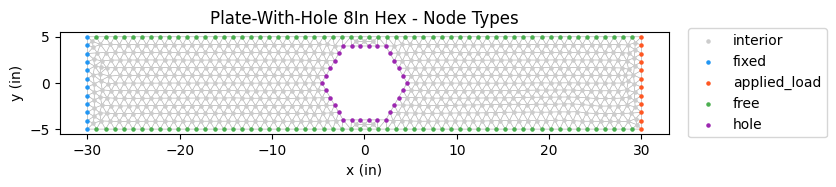

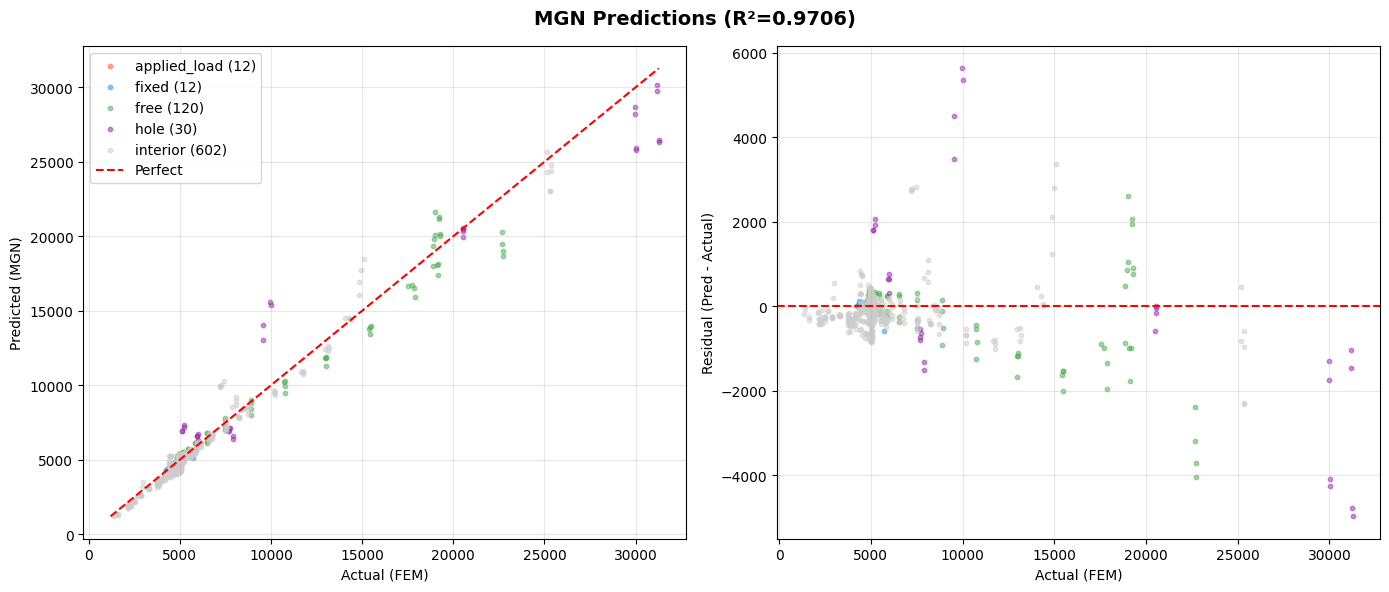

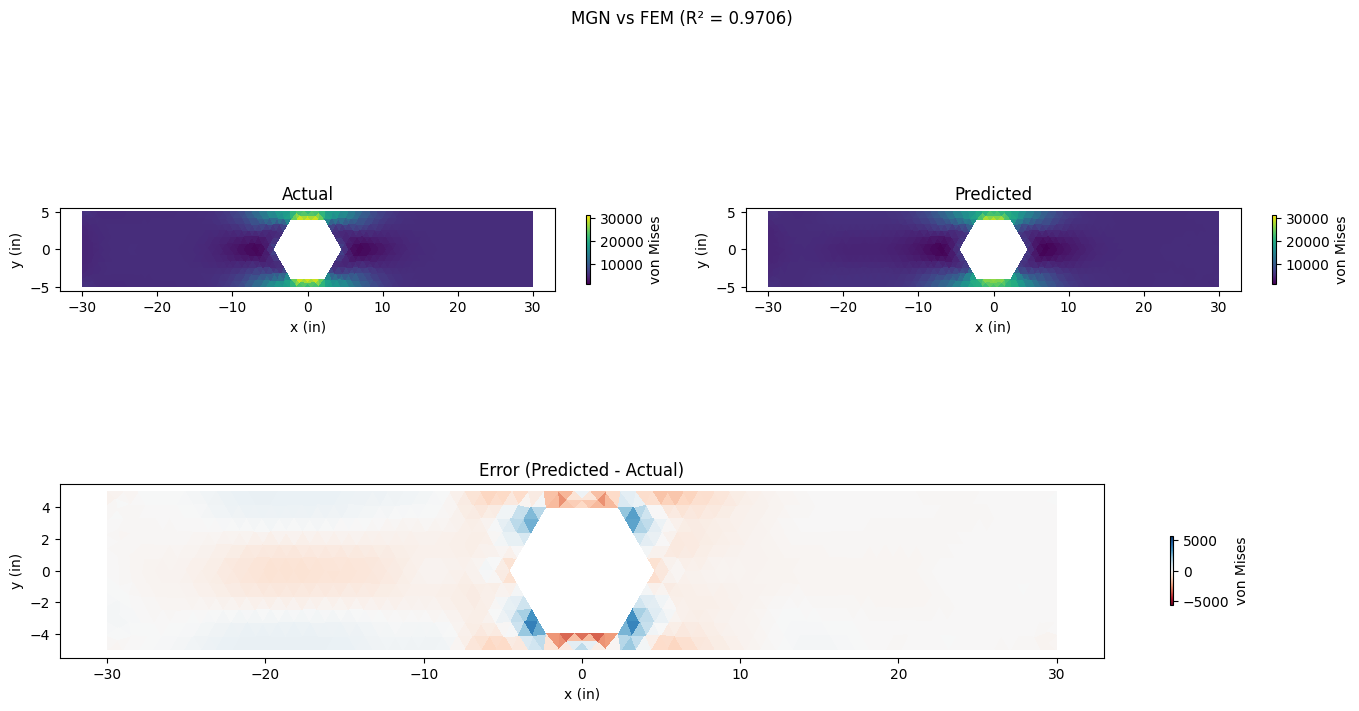

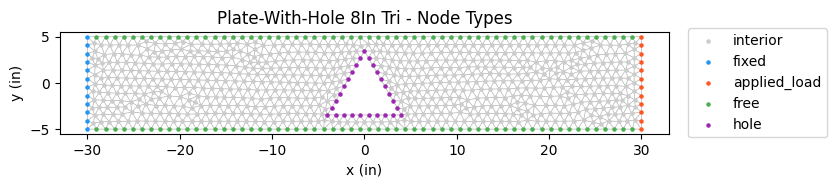

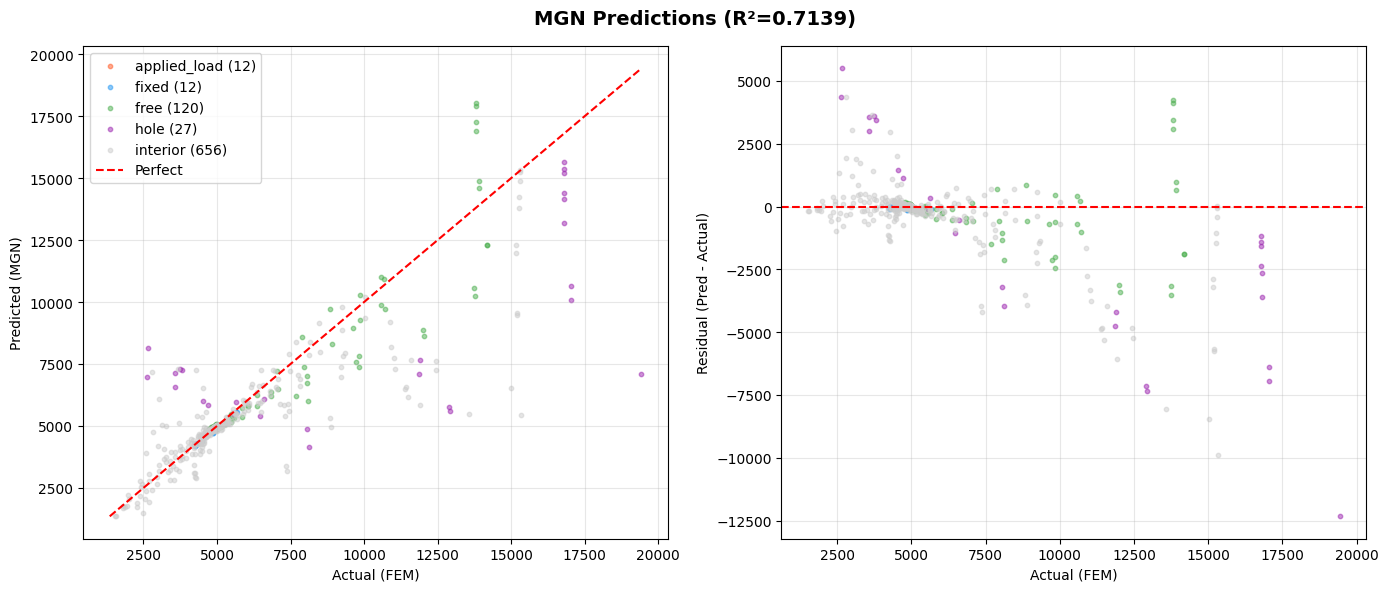

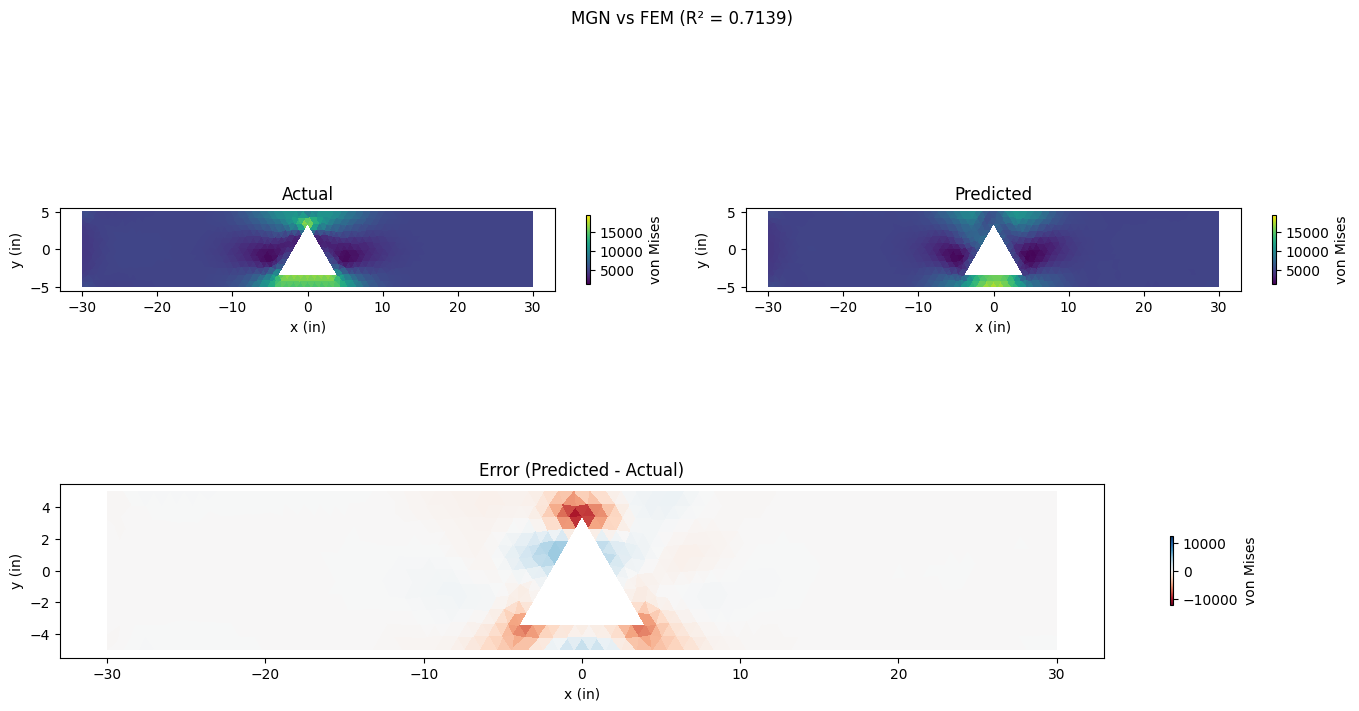

In [ ]:
if __name__ == "__main__":
    main()